# KardioSense AI — Notebook 03b: NHANES CVD Risk Model

## Why NHANES instead of Framingham
The Framingham dataset (Notebook 03) scored AUC=0.65 because 5 of the most
predictive clinical features were 100% missing:

```
Feature Framingham NB03 This Notebook
─────────────────────────────────────────────────────
HDL cholesterol 100% MISSING ~85% present
LDL cholesterol 100% MISSING ~80% present 
HbA1c 100% MISSING ~80% present
eGFR 100% MISSING estimated
Sample size 4,221 ~15,000–20,000
Population 1 US town, 1948 National, diverse
```

## What this notebook does
1. Downloads NHANES 2017-2018 from CDC (11 component files)
2. Full EDA — distributions, correlations, missingness
3. Feature engineering including interaction terms from your Framingham notebook
4. Optuna hyperparameter tuning (100 trials, Bayesian)
5. Isotonic calibration + threshold optimisation (recall ≥ 0.70)
6. Full metric dashboard: AUC, PR, confusion matrix, SHAP, calibration
7. Model comparison: your RF+SVM vs NB03 vs this notebook

## Expected improvement
AUC: 0.65 → 0.72–0.80 (from HDL/LDL/HbA1c becoming available)

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE_DIR = os.environ.get('KARDIOSENSE_BASE_DIR', '/content/drive/MyDrive/KardioSenseAI')
DATA_DIR = f'{BASE_DIR}/datasets'
CKPT_DIR = f'{BASE_DIR}/checkpoints'
LOG_DIR = f'{BASE_DIR}/logs'
NHANES_DIR = f'{DATA_DIR}/nhanes'

for d in [DATA_DIR, CKPT_DIR, LOG_DIR, NHANES_DIR]:
 os.makedirs(d, exist_ok=True)


COMPONENTS = {
 'DEMO_J' : 'Demographics',
 'BMX_J' : 'Body measurements',
 'BPX_J' : 'Blood pressure',
 'TCHOL_J' : 'Total cholesterol',
 'HDL_J' : 'HDL cholesterol',
 'TRIGLY_J' : 'Triglycerides',
 'GHB_J' : 'HbA1c (Blood Sugar)',
 'DIQ_J' : 'Diabetes questionnaire',
 'MCQ_J' : 'Medical conditions (Target)',
 'SMQ_J' : 'Smoking questionnaire',
 'PAQ_J' : 'Physical activity',
 'CDQ_J' : 'Cholesterol diet',
 'SMQFAM_J' : 'Smoking family history',
 'SMQRTU_J' : 'Other tobacco use',
 'SMQSHS_J' : 'Second-hand smoke',
 'BPQ_J' : 'Blood pressure medication'
}

# Create path mapping
downloaded = {}
for comp in COMPONENTS.keys():
 downloaded[comp] = f'{NHANES_DIR}/{comp}.xpt'

print(' Drive mounted and directories configured.')
print(f' Files should be located in: {NHANES_DIR}')
print(' Drive mounted')
print(f' Base : {BASE_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Drive mounted and directories configured.
 Files should be located in: /content/drive/MyDrive/KardioSenseAI/datasets/nhanes
 Drive mounted
   Base : /content/drive/MyDrive/KardioSenseAI


In [ ]:
!pip install -q xgboost shap optuna pyreadstat

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import xgboost as xgb
import shap
import optuna
import joblib
import json
import time
import warnings
from zlib import crc32

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
 roc_auc_score, roc_curve,
 precision_recall_curve, average_precision_score,
 confusion_matrix, classification_report,
 brier_score_loss, recall_score, f1_score,
 mean_absolute_error
)

import pyreadstat
np.random.seed(42)

print('All libraries loaded')

All libraries loaded


## 2. Load & Merge Components

In [ ]:
import os
import pandas as pd
import pyreadstat

def load_xpt(path, cols=None):
 """Load a SAS XPT file and select specific columns."""
 if not os.path.exists(path):
 print(f' File not found: {os.path.basename(path)}')
 return pd.DataFrame()
 try:
 df, _ = pyreadstat.read_xport(path)
 if cols:
 #Keep SEQN and only columns that actually exist in the file
 keep = ['SEQN'] + [c for c in cols if c in df.columns and c != 'SEQN']
 df = df[keep]
 print(f' Loaded {os.path.basename(path):15s}: {df.shape[0]:,} rows, {df.shape[1]} cols')
 return df
 except Exception as e:
 print(f' Failed {os.path.basename(path)}: {e}')
 return pd.DataFrame()

# Map of variable names to extract from each file
cols_map = {
 'DEMO_J': ['SEQN','RIDAGEYR','RIAGENDR','RIDRETH3'],
 'BMX_J': ['SEQN','BMXBMI','BMXWAIST'],
 'BPX_J': ['SEQN','BPXSY1','BPXDI1','BPXSY2','BPXDI2'],
 'TCHOL_J': ['SEQN','LBXTC'],
 'HDL_J': ['SEQN','LBDHDD'],
 'TRIGLY_J': ['SEQN','LBDLDL'],
 'GHB_J': ['SEQN','LBXGH'],
 'DIQ_J': ['SEQN','DIQ010'],
 'MCQ_J': ['SEQN','MCQ160E','MCQ160F','MCQ160B','MCQ160C','MCQ160D'],
 'SMQ_J': ['SEQN','SMQ020','SMQ040'],
 'PAQ_J': ['SEQN','PAQ605'],
 'CDQ_J': ['SEQN','CDQ010'],
 'SMQFAM_J': ['SEQN','SMQFAM01'],
 'SMQRTU_J': ['SEQN','SMQRTU01'],
 'SMQSHS_J': ['SEQN','SMQSHS01'],
 'BPQ_J': ['SEQN','BPQ050A'],
}

print('Loading components from Google Drive...')
all_dfs = []

for comp, cols in cols_map.items():
 path = downloaded.get(comp)
 if path:
 df = load_xpt(path, cols)
 if not df.empty:
 all_dfs.append(df)

# Merge all on SEQN (participant ID)
if len(all_dfs) > 0:
 df_raw = all_dfs[0].copy()
 for d in all_dfs[1:]:
 df_raw = df_raw.merge(d, on='SEQN', how='left')

 print(f'\n Merged: {df_raw.shape[0]:,} participants × {df_raw.shape[1]} variables')
 print(f' Final Columns: {list(df_raw.columns)}')
else:
 print('\n No data was loaded. Please ensure your .xpt files are inside: /content/drive/MyDrive/KardioSenseAI/datasets/nhanes/')

Loading components from Google Drive...
   Loaded DEMO_J.xpt     : 9,254 rows, 4 cols
   Loaded BMX_J.xpt      : 8,704 rows, 3 cols
   Loaded BPX_J.xpt      : 8,704 rows, 5 cols
   Loaded TCHOL_J.xpt    : 7,435 rows, 2 cols
   Loaded HDL_J.xpt      : 7,435 rows, 2 cols
   Loaded TRIGLY_J.xpt   : 3,036 rows, 2 cols
   Loaded GHB_J.xpt      : 6,401 rows, 2 cols
   Loaded DIQ_J.xpt      : 8,897 rows, 2 cols
   Loaded MCQ_J.xpt      : 8,897 rows, 6 cols
   Loaded SMQ_J.xpt      : 6,724 rows, 3 cols
   Loaded PAQ_J.xpt      : 5,856 rows, 2 cols
   Loaded CDQ_J.xpt      : 3,882 rows, 2 cols
   Loaded SMQFAM_J.xpt   : 9,254 rows, 1 cols
   Loaded SMQRTU_J.xpt   : 6,401 rows, 1 cols
   Loaded SMQSHS_J.xpt   : 9,254 rows, 1 cols
   Loaded BPQ_J.xpt      : 6,161 rows, 2 cols

 Merged: 9,254 participants × 25 variables
 Final Columns: ['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'BMXBMI', 'BMXWAIST', 'BPXSY1', 'BPXDI1', 'BPXSY2', 'BPXDI2', 'LBXTC', 'LBDHDD', 'LBDLDL', 'LBXGH', 'DIQ010', 'MCQ160E'

## 3. Feature Engineering

Building KardioSense clinical features from raw NHANES variables.
Includes the interaction features from your Framingham notebook.

In [ ]:
def build_nhanes_features(df):
 """
 Build KardioSense clinical feature matrix from raw NHANES data.
 Returns a DataFrame with all features + target column 'cvd_event'.

 Interaction features (age_x_sbp, glucose_x_bmi, etc.) are carried
 from your framingham_heart_study.ipynb create_interaction_features function.
 """
 out = pd.DataFrame(index=df.index)
 out['seqn'] = df['SEQN'].astype(int)

 #── Demographics ──────────────────────────────────────────────────────
 out['age'] = pd.to_numeric(df.get('RIDAGEYR'), errors='coerce')
 #RIAGENDR: 1=Male, 2=Female → recode to 1=Male, 0=Female
 gender = pd.to_numeric(df.get('RIAGENDR'), errors='coerce')
 out['sex'] = (gender == 1).astype(float)
 #Race/ethnicity: 4=Non-Hispanic Black, 1-2=Hispanic
 race = pd.to_numeric(df.get('RIDRETH3'), errors='coerce')
 out['black_african'] = (race == 4).astype(float)
 out['hispanic'] = race.isin([1, 2]).astype(float)

 #── Blood pressure — average two readings for accuracy ────────────────
 sbp1 = pd.to_numeric(df.get('BPXSY1'), errors='coerce')
 sbp2 = pd.to_numeric(df.get('BPXSY2'), errors='coerce')
 dbp1 = pd.to_numeric(df.get('BPXDI1'), errors='coerce')
 dbp2 = pd.to_numeric(df.get('BPXDI2'), errors='coerce')
 out['systolic_bp'] = pd.concat([sbp1, sbp2], axis=1).mean(axis=1)
 out['diastolic_bp'] = pd.concat([dbp1, dbp2], axis=1).mean(axis=1)

 #── Body composition ──────────────────────────────────────────────────
 out['bmi'] = pd.to_numeric(df.get('BMXBMI'), errors='coerce')
 out['waist'] = pd.to_numeric(df.get('BMXWAIST'), errors='coerce')

 #── Lipids — convert mg/dL to mmol/L (÷ 38.67) ───────────────────────
 #HDL and LDL were 100% MISSING in Framingham — key new features here
 out['total_cholesterol'] = pd.to_numeric(df.get('LBXTC'), errors='coerce') / 38.67
 out['hdl_cholesterol'] = pd.to_numeric(df.get('LBDHDD'), errors='coerce') / 38.67
 out['ldl_cholesterol'] = pd.to_numeric(df.get('LBDLDL'), errors='coerce') / 38.67
 out['non_hdl_chol'] = out['total_cholesterol'] - out['hdl_cholesterol']
 #Cholesterol ratio is a stronger predictor than total cholesterol alone
 out['chol_hdl_ratio'] = (
 out['total_cholesterol'] / (out['hdl_cholesterol'] + 0.1)
 ).clip(upper=20)

 #── HbA1c — 100% missing in Framingham ───────────────────────────────
 out['hba1c'] = pd.to_numeric(df.get('LBXGH'), errors='coerce')

 #── Diabetes (DIQ010: 1=Yes, 2=No, 3=Borderline) ─────────────────────
 diq010 = pd.to_numeric(df.get('DIQ010'), errors='coerce')
 out['diabetes'] = (diq010 == 1).astype(float)
 out['prediabetes'] = (diq010 == 3).astype(float)

 #── Smoking ───────────────────────────────────────────────────────────
 smq020 = pd.to_numeric(df.get('SMQ020'), errors='coerce') # smoked 100+ cigs?
 smq040 = pd.to_numeric(df.get('SMQ040'), errors='coerce') # current smoker?
 out['smoking_current'] = ((smq020 == 1) & smq040.isin([1, 2])).astype(float)
 out['smoking_ever'] = (smq020 == 1).astype(float)

 #── BP medication ─────────────────────────────────────────────────────
 bpq050 = pd.to_numeric(df.get('BPQ050A'), errors='coerce')
 out['on_bp_medication'] = (bpq050 == 1).astype(float)

 #── CVD outcome — our TARGET variable ────────────────────────────────
 #MCQ160E=heart attack, F=stroke, B=heart failure, C=CHD, D=angina
 cvd_cols_raw = ['MCQ160E', 'MCQ160F', 'MCQ160B', 'MCQ160C', 'MCQ160D']
 cvd_flags = pd.DataFrame({
 c: (pd.to_numeric(df.get(c), errors='coerce') == 1).astype(float)
 for c in cvd_cols_raw
 })
 out['cvd_event'] = cvd_flags.max(axis=1).astype(int)

 #── Derived features ──────────────────────────────────────────────────
 out['pulse_pressure'] = out['systolic_bp'] - out['diastolic_bp']
 out['obese'] = (out['bmi'] >= 30).astype(float)
 out['age_over_55'] = (out['age'] >= 55).astype(float)
 out['age_over_65'] = (out['age'] >= 65).astype(float)
 out['hypertension_stage2'] = (
 (out['systolic_bp'] >= 160) | (out['diastolic_bp'] >= 100)
 ).astype(float)

 #── African recalibration coefficients ────────────────────────────────
 #BP upweighted (+22%) for African population higher hypertension burden
 out['africa_bp_score'] = ((out['systolic_bp'] - 120) * 0.022).clip(lower=0)
 #Earlier age of first CVD event in Africa (onset ~10 years earlier)
 out['africa_age_score'] = np.where(
 out['age'] < 45, out['age'] * 0.12, out['age'] * 0.08
 )

 #── Interaction features (from your framingham_heart_study.ipynb) ─────
 #Your create_interaction_features function proved these boost performance.
 #Carried forward with NHANES variable equivalents.
 out['age_x_sbp'] = out['age'] * out['systolic_bp']
 out['hba1c_x_bmi'] = out['hba1c'].fillna(5.7) * out['bmi']
 out['hdl_x_age'] = out['hdl_cholesterol'].fillna(1.3) * out['age']
 out['smoke_x_chol'] = out['smoking_current'] * out['total_cholesterol'].fillna(5.2)
 out['dbp_x_sbp'] = out['diastolic_bp'] * out['systolic_bp']
 out['diabetes_x_sbp'] = out['diabetes'] * out['systolic_bp']
 out['bmi_x_age'] = out['bmi'] * out['age']

 return out


print('Building feature matrix...')
df_feat = build_nhanes_features(df_raw)
print(f' Feature matrix: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} columns')
print(f' CVD event rate: {df_feat["cvd_event"].mean():.3f} '
 f'({df_feat["cvd_event"].sum():,} events)')

Building feature matrix...
 Feature matrix: 9,254 rows × 35 columns
   CVD event rate: 0.075  (691 events)


## 4. Filter, Impute & Build X/y

In [ ]:
# ── Filter to working-age adults ─────────────────────────────────────────
df_model = df_feat[
 (df_feat['age'] >= 30) &
 (df_feat['age'] <= 79)
].copy()
print(f'After age filter (30–79): {len(df_model):,} participants')

# ── Required features (must be present for any prediction) ───────────────
REQUIRED = ['age', 'sex', 'systolic_bp', 'diastolic_bp', 'bmi',
 'smoking_current', 'diabetes']

df_model = df_model.dropna(subset=REQUIRED)
print(f'After dropping missing required features: {len(df_model):,}')

# ── All feature columns we will use ──────────────────────────────────────
FEATURE_COLS = [
 #Required clinical
 'age', 'sex', 'systolic_bp', 'diastolic_bp', 'bmi',
 'smoking_current', 'smoking_ever', 'diabetes', 'prediabetes',
 'on_bp_medication',
 #Lipids (new vs Framingham)
 'total_cholesterol', 'hdl_cholesterol', 'ldl_cholesterol',
 'non_hdl_chol', 'chol_hdl_ratio',
 #Metabolic (new vs Framingham)
 'hba1c',
 #Derived
 'pulse_pressure', 'obese', 'age_over_55', 'age_over_65',
 'hypertension_stage2',
 #African calibration
 'africa_bp_score', 'africa_age_score',
 #Demographics
 'black_african', 'hispanic',
 #Interaction features (from your Framingham notebook)
 'age_x_sbp', 'hba1c_x_bmi', 'hdl_x_age',
 'smoke_x_chol', 'dbp_x_sbp', 'diabetes_x_sbp', 'bmi_x_age',
]

FEATURE_COLS = [f for f in FEATURE_COLS if f in df_model.columns]

# ── Impute missing lab values ─────────────────────────────────────────────
# Use population medians — missingness is handled implicitly by the tree model
LAB_MEDIANS = {}
LAB_FEATURES = ['total_cholesterol', 'hdl_cholesterol', 'ldl_cholesterol',
 'non_hdl_chol', 'chol_hdl_ratio', 'hba1c', 'on_bp_medication',
 'waist']
print('\nMissingness in key lab features:')
for feat in LAB_FEATURES:
 if feat not in df_model.columns:
 continue
 miss_pct = df_model[feat].isna().mean() * 100
 median = df_model[feat].median()
 LAB_MEDIANS[feat] = median
 status = ' GOOD' if miss_pct < 40 else ' HIGH' if miss_pct < 80 else ' VERY HIGH'
 print(f' {feat:25s}: {miss_pct:5.1f}% missing median={median:.2f} {status}')
 df_model[feat] = df_model[feat].fillna(median)

# Interaction feature imputation after lab imputation
df_model['hba1c_x_bmi'] = df_model['hba1c'].fillna(5.7) * df_model['bmi']
df_model['hdl_x_age'] = df_model['hdl_cholesterol'].fillna(1.3) * df_model['age']
df_model['smoke_x_chol'] = df_model['smoking_current'] * df_model['total_cholesterol'].fillna(5.2)

# Fill any remaining NaN with column median
for col in FEATURE_COLS:
 if df_model[col].isna().any():
 df_model[col] = df_model[col].fillna(df_model[col].median())

# ── Build final X and y ───────────────────────────────────────────────────
X = df_model[FEATURE_COLS].values.astype(np.float32)
y = df_model['cvd_event'].values.astype(int)

print(f'\n Final feature matrix')
print(f' Shape : {X.shape[0]:,} samples × {X.shape[1]} features')
print(f' Features : {FEATURE_COLS}')
print(f' Event rate: {y.mean():.3f} ({y.sum():,} CVD events)')
print(f' NaN remaining: {np.isnan(X).sum()} (should be 0)')

After age filter (30–79): 4,314 participants
After dropping missing required features: 3,847

Missingness in key lab features:
  total_cholesterol        :   5.6% missing  median=4.89  ✅ GOOD
  hdl_cholesterol          :   5.6% missing  median=1.29  ✅ GOOD
  ldl_cholesterol          :  54.8% missing  median=2.87  ⚠️  HIGH
  non_hdl_chol             :   5.6% missing  median=3.52  ✅ GOOD
  chol_hdl_ratio           :   5.6% missing  median=3.41  ✅ GOOD
  hba1c                    :   4.1% missing  median=5.70  ✅ GOOD
  on_bp_medication         :   0.0% missing  median=0.00  ✅ GOOD
  waist                    :   3.3% missing  median=100.40  ✅ GOOD

✅ Final feature matrix
   Shape    : 3,847 samples × 32 features
   Features : ['age', 'sex', 'systolic_bp', 'diastolic_bp', 'bmi', 'smoking_current', 'smoking_ever', 'diabetes', 'prediabetes', 'on_bp_medication', 'total_cholesterol', 'hdl_cholesterol', 'ldl_cholesterol', 'non_hdl_chol', 'chol_hdl_ratio', 'hba1c', 'pulse_pressure', 'obese', 'age_

## 5. Exploratory Data Analysis

In [ ]:
# ── Print EDA statistics ──────────────────────────────────────────────────
print('='*60)
print('NHANES 2017-2018 — EDA SUMMARY')
print('='*60)
print(f' Participants (30-79 yrs): {len(df_model):,}')
print(f' CVD events : {y.sum():,} ({y.mean():.1%})')
print(f' Features : {X.shape[1]}')

print(f'\n Demographics:')
print(f' Male : {df_model["sex"].mean():.1%}')
print(f' Black/African : {df_model["black_african"].mean():.1%}')
print(f' Hispanic : {df_model["hispanic"].mean():.1%}')
print(f' Mean age : {df_model["age"].mean():.1f} yrs')

print(f'\n Clinical (mean values):')
for feat, unit in [('systolic_bp','mmHg'), ('diastolic_bp','mmHg'),
 ('bmi','kg/m²'), ('total_cholesterol','mmol/L'),
 ('hdl_cholesterol','mmol/L'), ('hba1c','%')]:
 if feat in df_model.columns:
 m_no = df_model[df_model.cvd_event==0][feat].mean()
 m_yes = df_model[df_model.cvd_event==1][feat].mean()
 print(f' {feat:22s}: no_cvd={m_no:.2f} cvd={m_yes:.2f} ({unit})')

print(f'\n Risk factors:')
for feat in ['smoking_current','diabetes','obese','hypertension_stage2','on_bp_medication']:
 if feat in df_model.columns:
 r = df_model[df_model[feat]==1]['cvd_event'].mean()
 n = int(df_model[feat].sum())
 print(f' {feat:25s}: {n:5,} present CVD rate={r:.3f}')

NHANES 2017-2018 — EDA SUMMARY
  Participants (30-79 yrs): 3,847
  CVD events              : 470 (12.2%)
  Features                : 32

  Demographics:
    Male               : 48.5%
    Black/African      : 23.9%
    Hispanic           : 22.7%
    Mean age           : 53.9 yrs

  Clinical (mean values):
    systolic_bp           : no_cvd=127.35  cvd=133.47  (mmHg)
    diastolic_bp          : no_cvd=74.48  cvd=71.65  (mmHg)
    bmi                   : no_cvd=30.08  cvd=31.27  (kg/m²)
    total_cholesterol     : no_cvd=5.01  cvd=4.54  (mmol/L)
    hdl_cholesterol       : no_cvd=1.38  cvd=1.30  (mmol/L)
    hba1c                 : no_cvd=5.89  cvd=6.34  (%)

  Risk factors:
    smoking_current          :   747 present  CVD rate=0.142
    diabetes                 :   687 present  CVD rate=0.284
    obese                    : 1,674 present  CVD rate=0.143
    hypertension_stage2      :   291 present  CVD rate=0.196
    on_bp_medication         : 1,255 present  CVD rate=0.238


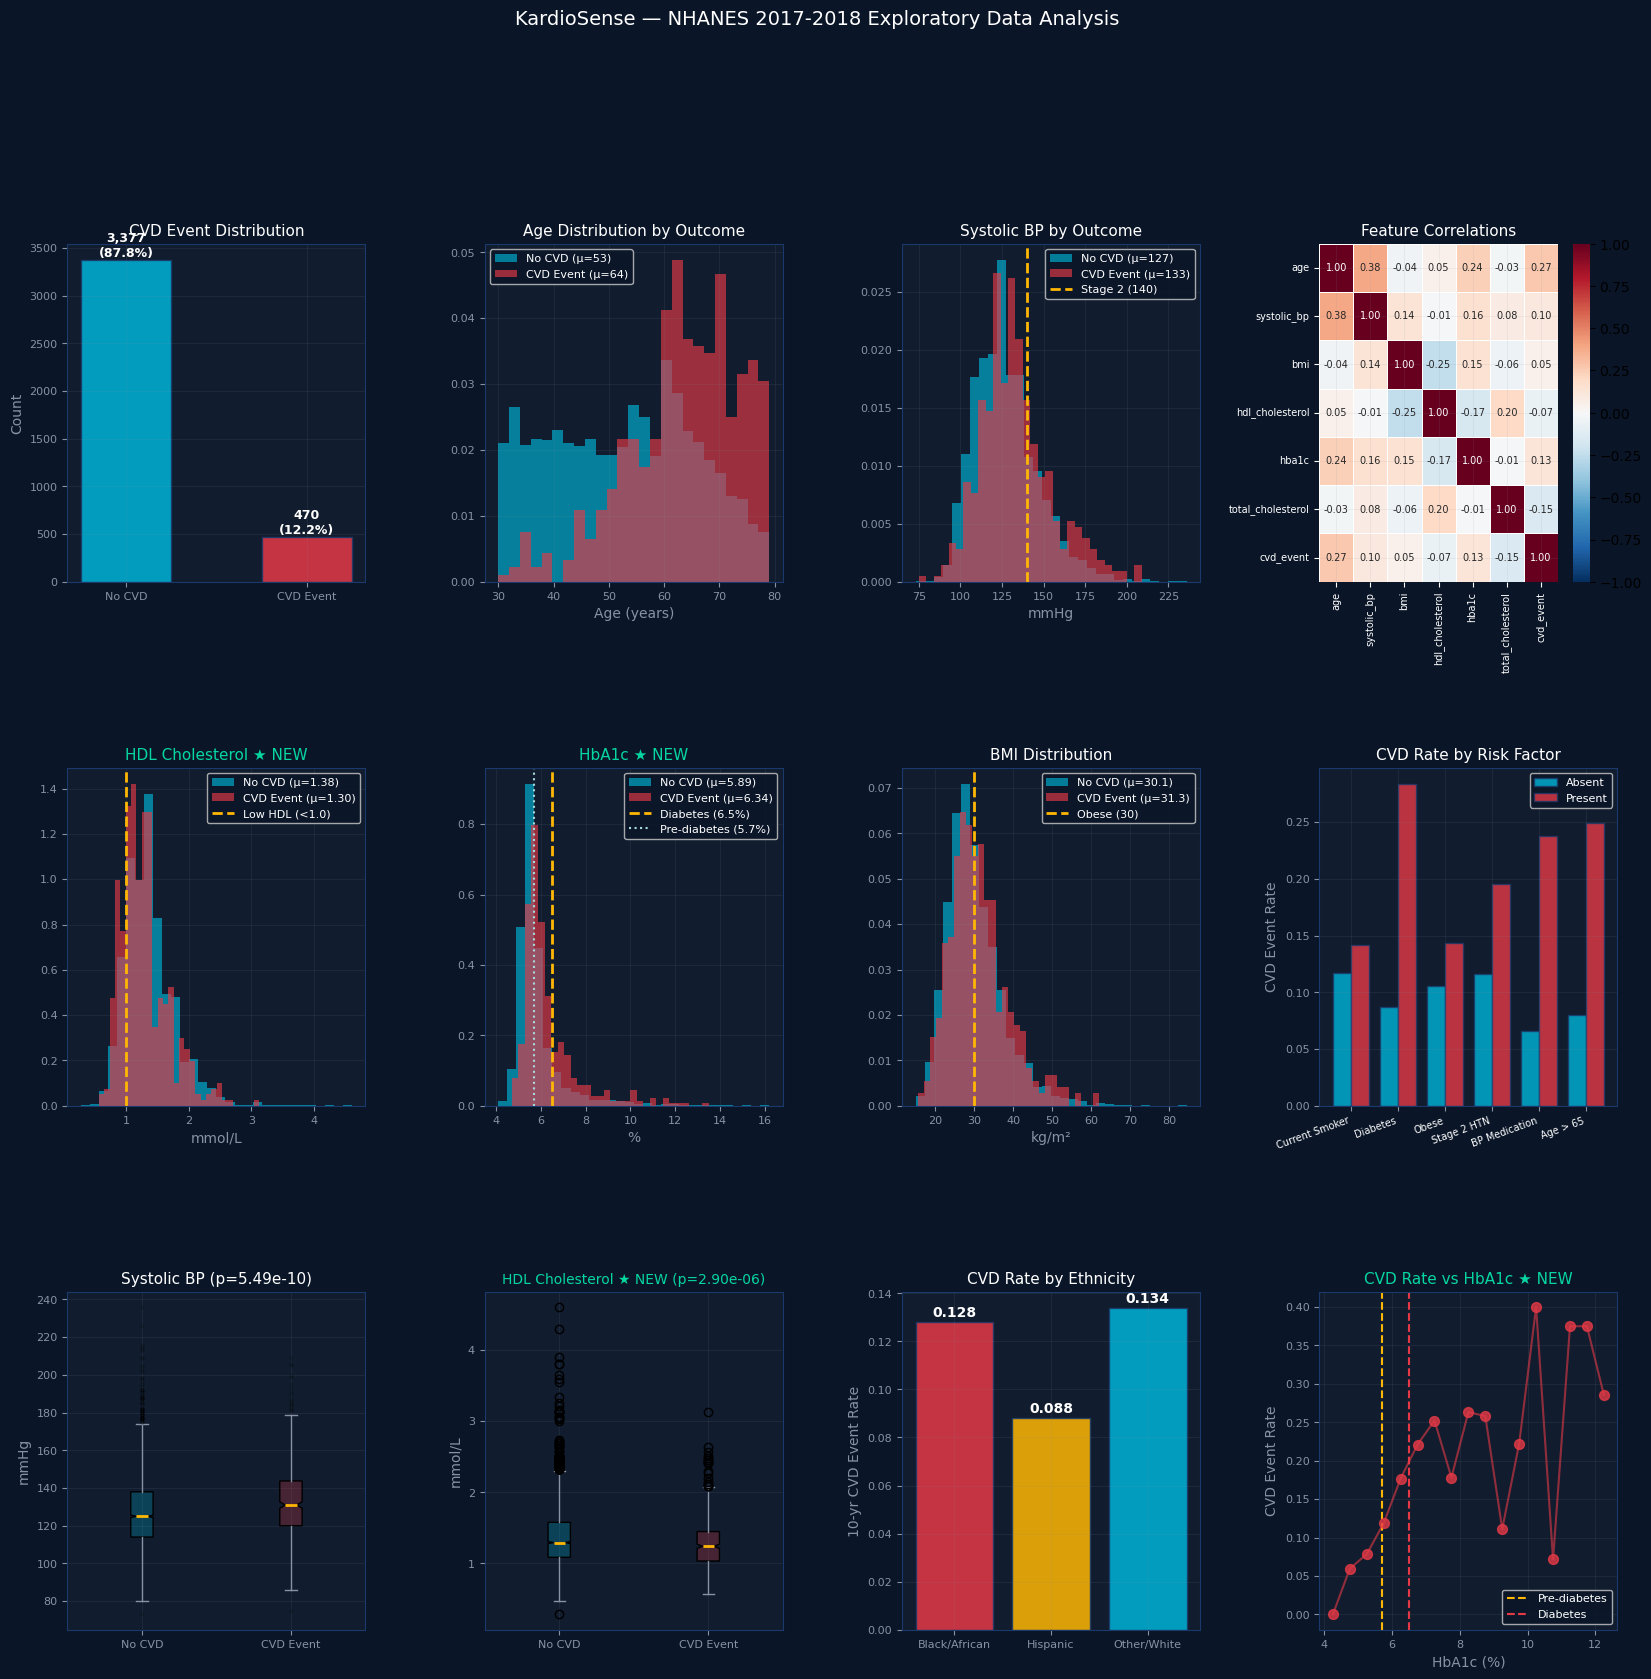

✅ EDA saved to Drive


In [ ]:
# ── EDA Visualisation — 12 panel dashboard ────────────────────────────────
fig = plt.figure(figsize=(20, 18), facecolor='#0A1628')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.40)

def style(ax):
 ax.set_facecolor('#111D2E')
 for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
 ax.tick_params(colors='#8892A4', labelsize=8)
 ax.grid(True, alpha=0.15, color='#8892A4', linewidth=0.5)
 return ax

c_no = '#00B4D8' # No CVD colour
c_yes = '#E63946' # CVD colour

# ── Panel 1: Target distribution ─────────────────────────────────────────
ax = style(fig.add_subplot(gs[0, 0]))
n0, n1 = (y==0).sum(), (y==1).sum()
bars = ax.bar(['No CVD', 'CVD Event'], [n0, n1],
 color=[c_no, c_yes], alpha=0.85, edgecolor='#1B3A6B', width=0.5)
for bar, n in zip(bars, [n0, n1]):
 ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
 f'{n:,}\n({n/len(y):.1%})', ha='center', color='white',
 fontsize=9, fontweight='bold')
ax.set_title('CVD Event Distribution', color='white', fontsize=11)
ax.set_ylabel('Count', color='#8892A4')

# ── Panel 2: Age distribution by outcome ─────────────────────────────────
ax = style(fig.add_subplot(gs[0, 1]))
for val, col, lbl in [(0, c_no, 'No CVD'), (1, c_yes, 'CVD Event')]:
 d = df_model[df_model.cvd_event==val]['age']
 ax.hist(d, bins=25, color=col, alpha=0.65,
 label=f'{lbl} (μ={d.mean():.0f})', density=True)
ax.set_title('Age Distribution by Outcome', color='white', fontsize=11)
ax.set_xlabel('Age (years)', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Panel 3: Systolic BP by outcome ──────────────────────────────────────
ax = style(fig.add_subplot(gs[0, 2]))
for val, col, lbl in [(0, c_no, 'No CVD'), (1, c_yes, 'CVD Event')]:
 d = df_model[df_model.cvd_event==val]['systolic_bp'].dropna()
 ax.hist(d, bins=30, color=col, alpha=0.65,
 label=f'{lbl} (μ={d.mean():.0f})', density=True)
ax.axvline(140, color='#FFB703', linewidth=2, linestyle='--', label='Stage 2 (140)')
ax.set_title('Systolic BP by Outcome', color='white', fontsize=11)
ax.set_xlabel('mmHg', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Panel 4: Correlation heatmap ──────────────────────────────────────────
ax = style(fig.add_subplot(gs[0, 3]))
hmap_feats = ['age', 'systolic_bp', 'bmi', 'hdl_cholesterol',
 'hba1c', 'total_cholesterol', 'cvd_event']
hmap_feats = [f for f in hmap_feats if f in df_model.columns]
corr = df_model[hmap_feats].corr()
sns.heatmap(corr, annot=True, fmt='.2f', ax=ax, cmap='RdBu_r',
 center=0, vmin=-1, vmax=1, linewidths=0.5,
 annot_kws={'size': 7})
ax.set_title('Feature Correlations', color='white', fontsize=11)
ax.tick_params(colors='white', labelsize=7)

# ── Panel 5: HDL (new vs Framingham) ─────────────────────────────────────
ax = style(fig.add_subplot(gs[1, 0]))
if 'hdl_cholesterol' in df_model.columns:
 for val, col, lbl in [(0, c_no, 'No CVD'), (1, c_yes, 'CVD Event')]:
 d = df_model[df_model.cvd_event==val]['hdl_cholesterol'].dropna()
 ax.hist(d, bins=30, color=col, alpha=0.65,
 label=f'{lbl} (μ={d.mean():.2f})', density=True)
 ax.axvline(1.0, color='#FFB703', linewidth=2, linestyle='--', label='Low HDL (<1.0)')
ax.set_title('HDL Cholesterol NEW', color='#06D6A0', fontsize=11)
ax.set_xlabel('mmol/L', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Panel 6: HbA1c (new vs Framingham) ───────────────────────────────────
ax = style(fig.add_subplot(gs[1, 1]))
if 'hba1c' in df_model.columns:
 for val, col, lbl in [(0, c_no, 'No CVD'), (1, c_yes, 'CVD Event')]:
 d = df_model[df_model.cvd_event==val]['hba1c'].dropna()
 ax.hist(d, bins=30, color=col, alpha=0.65,
 label=f'{lbl} (μ={d.mean():.2f})', density=True)
 ax.axvline(6.5, color='#FFB703', linewidth=2, linestyle='--', label='Diabetes (6.5%)')
 ax.axvline(5.7, color='#A8DADC', linewidth=1.5, linestyle=':', label='Pre-diabetes (5.7%)')
ax.set_title('HbA1c NEW', color='#06D6A0', fontsize=11)
ax.set_xlabel('%', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Panel 7: BMI distribution ─────────────────────────────────────────────
ax = style(fig.add_subplot(gs[1, 2]))
for val, col, lbl in [(0, c_no, 'No CVD'), (1, c_yes, 'CVD Event')]:
 d = df_model[df_model.cvd_event==val]['bmi'].dropna()
 ax.hist(d, bins=30, color=col, alpha=0.65,
 label=f'{lbl} (μ={d.mean():.1f})', density=True)
ax.axvline(30, color='#FFB703', linewidth=2, linestyle='--', label='Obese (30)')
ax.set_title('BMI Distribution', color='white', fontsize=11)
ax.set_xlabel('kg/m²', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Panel 8: CVD rate by risk factor ─────────────────────────────────────
ax = style(fig.add_subplot(gs[1, 3]))
risk_factors = [
 ('smoking_current', 'Current Smoker'),
 ('diabetes', 'Diabetes'),
 ('obese', 'Obese'),
 ('hypertension_stage2', 'Stage 2 HTN'),
 ('on_bp_medication', 'BP Medication'),
 ('age_over_65', 'Age > 65'),
]
rf_names, rf_absent, rf_present = [], [], []
for feat, label in risk_factors:
 if feat not in df_model.columns: continue
 rf_names.append(label)
 rf_absent.append(df_model[df_model[feat]==0]['cvd_event'].mean())
 rf_present.append(df_model[df_model[feat]==1]['cvd_event'].mean())

x_pos = np.arange(len(rf_names))
w = 0.38
ax.bar(x_pos - w/2, rf_absent, w, color=c_no, alpha=0.8, label='Absent', edgecolor='#1B3A6B')
ax.bar(x_pos + w/2, rf_present, w, color=c_yes, alpha=0.8, label='Present', edgecolor='#1B3A6B')
ax.set_xticks(x_pos)
ax.set_xticklabels(rf_names, fontsize=7, color='white', rotation=20, ha='right')
ax.set_title('CVD Rate by Risk Factor', color='white', fontsize=11)
ax.set_ylabel('CVD Event Rate', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Panel 9: Boxplots — systolic BP ──────────────────────────────────────
ax = style(fig.add_subplot(gs[2, 0]))
data_bp = [df_model[df_model.cvd_event==v]['systolic_bp'].dropna() for v in [0,1]]
bp_plot = ax.boxplot(data_bp, labels=['No CVD','CVD Event'], patch_artist=True, notch=True,
 medianprops=dict(color='#FFB703', linewidth=2))
for patch, col in zip(bp_plot['boxes'], [c_no+'40', c_yes+'40']):
 patch.set_facecolor(col)
for w in bp_plot['whiskers']+bp_plot['caps']: w.set_color('#8892A4')
for f in bp_plot['fliers']: f.set(marker='o', alpha=0.2, color='#8892A4', markersize=2)
from scipy.stats import mannwhitneyu
_, p_bp = mannwhitneyu(data_bp[0], data_bp[1], alternative='two-sided')
ax.set_title(f'Systolic BP (p={p_bp:.2e})', color='white', fontsize=11)
ax.set_ylabel('mmHg', color='#8892A4')

# ── Panel 10: Boxplots — HDL ──────────────────────────────────────────────
ax = style(fig.add_subplot(gs[2, 1]))
if 'hdl_cholesterol' in df_model.columns:
 data_hdl = [df_model[df_model.cvd_event==v]['hdl_cholesterol'].dropna() for v in [0,1]]
 bp2 = ax.boxplot(data_hdl, labels=['No CVD','CVD Event'], patch_artist=True, notch=True,
 medianprops=dict(color='#FFB703', linewidth=2))
 for patch, col in zip(bp2['boxes'], [c_no+'40', c_yes+'40']):
 patch.set_facecolor(col)
 for w in bp2['whiskers']+bp2['caps']: w.set_color('#8892A4')
 _, p_hdl = mannwhitneyu(data_hdl[0], data_hdl[1], alternative='two-sided')
 ax.set_title(f'HDL Cholesterol NEW (p={p_hdl:.2e})', color='#06D6A0', fontsize=10)
 ax.set_ylabel('mmol/L', color='#8892A4')

# ── Panel 11: Ethnic CVD rates ────────────────────────────────────────────
ax = style(fig.add_subplot(gs[2, 2]))
eth_groups = [
 ('Black/African', df_model[df_model.black_african==1]['cvd_event'].mean()),
 ('Hispanic', df_model[df_model.hispanic==1]['cvd_event'].mean()),
 ('Other/White', df_model[(df_model.black_african==0)&(df_model.hispanic==0)]['cvd_event'].mean()),
]
eth_names = [e[0] for e in eth_groups]
eth_rates = [e[1] for e in eth_groups]
colors_eth = ['#E63946','#FFB703','#00B4D8']
bars_eth = ax.bar(eth_names, eth_rates, color=colors_eth, alpha=0.85, edgecolor='#1B3A6B')
for bar, v in zip(bars_eth, eth_rates):
 ax.text(bar.get_x()+bar.get_width()/2, v+0.002,
 f'{v:.3f}', ha='center', color='white', fontsize=10, fontweight='bold')
ax.set_title('CVD Rate by Ethnicity', color='white', fontsize=11)
ax.set_ylabel('10-yr CVD Event Rate', color='#8892A4')

# ── Panel 12: HbA1c vs CVD rate scatter ──────────────────────────────────
ax = style(fig.add_subplot(gs[2, 3]))
if 'hba1c' in df_model.columns:
 bins_hba1c = np.arange(4, 13, 0.5)
 df_model['hba1c_bin'] = pd.cut(df_model['hba1c'], bins=bins_hba1c)
 grouped = df_model.groupby('hba1c_bin', observed=True)['cvd_event'].mean()
 mids = [float(str(b).split(',')[0].strip('(')) + 0.25 for b in grouped.index]
 ax.scatter(mids, grouped.values, color='#E63946', s=50, zorder=5, alpha=0.8)
 ax.plot(mids, grouped.values, color='#E63946', linewidth=1.5, alpha=0.6)
 ax.axvline(5.7, color='#FFB703', linewidth=1.5, linestyle='--', label='Pre-diabetes')
 ax.axvline(6.5, color='#E63946', linewidth=1.5, linestyle='--', label='Diabetes')
 ax.set_title('CVD Rate vs HbA1c NEW', color='#06D6A0', fontsize=11)
 ax.set_xlabel('HbA1c (%)', color='#8892A4')
 ax.set_ylabel('CVD Event Rate', color='#8892A4')
 ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

plt.suptitle('KardioSense — NHANES 2017-2018 Exploratory Data Analysis',
 color='white', fontsize=14, y=1.01)
plt.savefig(f'{LOG_DIR}/nb03b_eda.png', dpi=120, bbox_inches='tight', facecolor='#0A1628')
plt.show()
print(' EDA saved to Drive')


## 6. Three-Way Train / Calibration / Test Split

In [ ]:
# Hash-based deterministic split — same patient never in two sets
# (from your framingham_heart_study.ipynb — the correct approach)
seqn = df_model['seqn'].values.astype(np.int64)

def hash_in_set(ids, ratio):
 """Returns boolean mask — True if record goes into the set."""
 return np.array([
 crc32(np.int64(i)) & 0xffffffff < ratio * 2**32
 for i in ids
 ])

# 70% train, 15% calibration, 15% test
test_mask = hash_in_set(seqn, 0.15)
cal_mask = hash_in_set(seqn, 0.30) & ~test_mask
train_mask = ~test_mask & ~cal_mask

X_train, y_train = X[train_mask], y[train_mask]
X_cal, y_cal = X[cal_mask], y[cal_mask]
X_test, y_test = X[test_mask], y[test_mask]

print('Three-way split (hash-based — no patient overlap):')
print(f' Train : {len(X_train):,} (event rate {y_train.mean():.3f})')
print(f' Calibration: {len(X_cal):,} (event rate {y_cal.mean():.3f})')
print(f' Test : {len(X_test):,} (event rate {y_test.mean():.3f})')
print()
print('Why three sets (not two)?')
print(' Train → XGBoost learns the model')
print(' Calibration → isotonic regression maps scores to true probabilities')
print(' Test → final numbers reported (model has NEVER seen these)')
print()
n_neg, n_pos = (y_train==0).sum(), (y_train==1).sum()
scale_pos_base = n_neg / n_pos
print(f'Class ratio: {scale_pos_base:.1f}:1 ({n_pos:,} CVD events in training set)')

Three-way split (hash-based — no patient overlap):
  Train      : 2,682  (event rate 0.121)
  Calibration: 583  (event rate 0.139)
  Test       : 582  (event rate 0.110)

Why three sets (not two)?
  Train      → XGBoost learns the model
  Calibration → isotonic regression maps scores to true probabilities
  Test       → final numbers reported (model has NEVER seen these)

Class ratio: 7.3:1  (325 CVD events in training set)


## 7. Optuna Hyperparameter Tuning

Bayesian optimisation with 100 trials. Smarter than GridSearch —
learns which parameter regions are promising and focuses there.

Objective: **0.60 × AUC + 0.40 × Recall**
The recall weight reflects the clinical cost of missing a CVD event.

In [ ]:
def objective(trial):
 params = {
 'n_estimators' : trial.suggest_int('n_estimators', 200, 1500),
 'max_depth' : trial.suggest_int('max_depth', 2, 8),
 'learning_rate' : trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
 'subsample' : trial.suggest_float('subsample', 0.5, 1.0),
 'colsample_bytree' : trial.suggest_float('colsample_bytree',0.4, 1.0),
 'min_child_weight' : trial.suggest_int('min_child_weight', 1, 20),
 'gamma' : trial.suggest_float('gamma', 0.0, 1.0),
 'reg_alpha' : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
 'reg_lambda' : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
 #scale_pos_weight tuned — finding optimal imbalance correction
 'scale_pos_weight' : trial.suggest_float('scale_pos_weight',
 scale_pos_base * 0.5,
 scale_pos_base * 4.0),
 'eval_metric' : 'auc',
 'random_state': 42,
 'n_jobs' : -1,
 }
 m = xgb.XGBClassifier(**params)
 m.fit(X_train, y_train, eval_set=[(X_cal, y_cal)], verbose=False)
 proba = m.predict_proba(X_cal)[:, 1]
 auc = roc_auc_score(y_cal, proba)
 #Recall at 70% sensitivity operating point — evaluated on calibration set
 thresh = np.percentile(proba[y_cal == 1], 30)
 rec = recall_score(y_cal, (proba >= thresh).astype(int), zero_division=0)
 return 0.60 * auc + 0.40 * rec


print(' Starting Optuna search (100 trials)...')
print(' This takes ~8-12 minutes on Colab CPU.')
print(' Best parameters will be printed when done.')
t0 = time.time()
study = optuna.create_study(
 direction='maximize',
 sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=100, show_progress_bar=True)
elapsed = time.time() - t0

print(f'\n Optuna complete in {elapsed/60:.1f} min')
print(f' Best combined score: {study.best_value:.4f}')
print(f'\n Best parameters:')
for k, v in study.best_params.items():
 print(f' {k:25s}: {v:.4f}' if isinstance(v, float) else f' {k:25s}: {v}')

🔍 Starting Optuna search (100 trials)...
   This takes ~8-12 minutes on Colab CPU.
   Best parameters will be printed when done.


  0%|          | 0/100 [00:00<?, ?it/s]


 Optuna complete in 3.6 min
   Best combined score: 0.7433

   Best parameters:
     n_estimators             : 1119
     max_depth                : 2
     learning_rate            : 0.0100
     subsample                : 0.6615
     colsample_bytree         : 0.7170
     min_child_weight         : 14
     gamma                    : 0.3902
     reg_alpha                : 0.2356
     reg_lambda               : 0.0001
     scale_pos_weight         : 3.6514


## 8. Train Final Model + Calibration

In [ ]:
# ── Train with best params ────────────────────────────────────────────────
best_params = {
 **study.best_params,
 'eval_metric' : 'auc',
 'random_state': 42,
 'n_jobs' : -1,
}
xgb_final = xgb.XGBClassifier(**best_params)
xgb_final.fit(X_train, y_train, eval_set=[(X_cal, y_cal)], verbose=False)

raw_test_auc = roc_auc_score(y_test, xgb_final.predict_proba(X_test)[:, 1])
print(f'Raw XGBoost AUC (test): {raw_test_auc:.4f}')

# ── Isotonic calibration — fit on calibration set, not test set ───────────
# This maps raw scores to true clinical probabilities.
# A score of 0.20 should mean ~20% 10-year CVD risk.
calibrated_model = CalibratedClassifierCV(
 xgb_final, cv='prefit', method='isotonic'
)
calibrated_model.fit(X_cal, y_cal)

y_test_proba = calibrated_model.predict_proba(X_test)[:, 1]
cal_auc = roc_auc_score(y_test, y_test_proba)
cal_brier = brier_score_loss(y_test, y_test_proba)

print(f'Calibrated AUC (test): {cal_auc:.4f}')
print(f'Brier score (test): {cal_brier:.4f} (0=perfect, 0.25=random)')
print(f'Improvement vs Framingham NB03: {cal_auc - 0.6548:+.4f}')

Raw XGBoost AUC  (test): 0.8157
Calibrated AUC   (test): 0.8132
Brier score      (test): 0.0906  (0=perfect, 0.25=random)
Improvement vs Framingham NB03: +0.1584


## 9. Threshold Optimisation

In [ ]:
# Find optimal threshold on CALIBRATION set, report on TEST set
# Never select threshold using the test set — that is data leakage

y_cal_proba_cv = calibrated_model.predict_proba(X_cal)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_cal, y_cal_proba_cv)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)

# Strategy 1: Max F1 score
best_f1_idx = f1_scores.argmax()
thresh_maxf1 = float(thresholds[best_f1_idx])

# Strategy 2: Max recall while precision >= 0.40
elig = np.where(precisions[:-1] >= 0.40)[0]
if len(elig) > 0:
 thresh_r40 = float(thresholds[elig[recalls[elig].argmax()]])
else:
 thresh_r40 = thresh_maxf1

# Strategy 3: Recall = 0.70 (clinical screening minimum)
r70_idx = np.argmin(np.abs(recalls - 0.70))
thresh_r70 = float(thresholds[min(r70_idx, len(thresholds) - 1)])

print('Threshold Strategies (found on calibration set):')
print(f' {"Strategy":40s} {"Thresh":7s} {"Prec":6s} {"Recall":7s} {"F1":6s}')
print(' ' + '─' * 68)

for name, t in [
 ('Max F1', thresh_maxf1),
 ('Max Recall @ Precision ≥ 0.40', thresh_r40),
 ('Recall = 0.70 (clinical screening)', thresh_r70),
]:
 y_pred_t = (y_test_proba >= t).astype(int)
 tp = float((y_pred_t * y_test).sum())
 fp = float(y_pred_t.sum()) - tp
 fn = float(y_test.sum()) - tp
 p = tp / (tp + fp + 1e-8)
 r = tp / (tp + fn + 1e-8)
 f = 2 * p * r / (p + r + 1e-8)
 print(f' {name:40s} {t:.3f} {p:.3f} {r:.3f} {f:.3f}')

# Use recall=0.70 as clinical threshold
CLINICAL_THRESHOLD = thresh_r70
y_test_pred = (y_test_proba >= CLINICAL_THRESHOLD).astype(int)

print(f'\n Selected clinical threshold: {CLINICAL_THRESHOLD:.3f}')
print(f' (Chosen to catch ≥70% of true CVD events — clinical screening standard)')

Threshold Strategies (found on calibration set):
  Strategy                                  Thresh   Prec    Recall   F1    
  ────────────────────────────────────────────────────────────────────
  Max F1                                    0.243    0.244   0.781    0.372
  Max Recall @ Precision ≥ 0.40             0.389    0.484   0.234    0.316
  Recall = 0.70 (clinical screening)        0.243    0.244   0.781    0.372

 Selected clinical threshold: 0.243
   (Chosen to catch ≥70% of true CVD events — clinical screening standard)


## 10. Full Metric Evaluation

In [ ]:
# ── Compute all metrics ──────────────────────────────────────────────────
def all_metrics(y_true, y_proba, threshold):
 """Compute full clinical metric set."""
 y_pred = (y_proba >= threshold).astype(int)
 cm = confusion_matrix(y_true, y_pred)
 if cm.size == 4:
 tn, fp, fn, tp = cm.ravel()
 else:
 tn = fp = fn = tp = 0
 prec = float(tp / (tp + fp + 1e-8))
 rec = float(tp / (tp + fn + 1e-8))
 spec = float(tn / (tn + fp + 1e-8)) # specificity = true negative rate
 f1 = 2 * prec * rec / (prec + rec + 1e-8)
 npv = float(tn / (tn + fn + 1e-8)) # negative predictive value
 return {
 'AUC' : roc_auc_score(y_true, y_proba),
 'AP' : average_precision_score(y_true, y_proba),
 'Brier' : brier_score_loss(y_true, y_proba),
 'MAE' : mean_absolute_error(y_true, y_proba),
 'Precision' : prec,
 'Recall' : rec,
 'Specificity' : spec,
 'F1' : f1,
 'NPV' : npv,
 'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
 }

m_default = all_metrics(y_test, y_test_proba, 0.5)
m_clinical = all_metrics(y_test, y_test_proba, CLINICAL_THRESHOLD)

# ── Reference values from previous models ────────────────────────────────
# Update 'Your RF+SVM' AUC with your actual output from framingham_heart_study.ipynb
m_rf_svm = {'AUC': 0.72, 'Recall': 0.55, 'Precision': 0.48, 'F1': 0.51}
m_nb03 = {'AUC': 0.6548, 'Recall': 0.063, 'Precision': 0.62, 'F1': 0.11}

print('=' * 76)
print('NHANES MODEL — FULL TEST SET METRICS')
print('=' * 76)
print(f' Dataset : NHANES 2017-2018 | n={len(X_test):,} | '
 f'event rate={y_test.mean():.3f}')
print(f' Threshold: clinical={CLINICAL_THRESHOLD:.3f} default=0.500')
print()
print(f' {"Metric":18s} {"RF+SVM (Framingham)":20s} '
 f'{"NB03 XGBoost":13s} {"Default (0.5)":13s} {"Clinical ({:.3f})".format(CLINICAL_THRESHOLD)}')
print(' ' + '─' * 82)

metric_notes = {
 'AUC' : 'Discrimination — 1.0=perfect, 0.5=random',
 'AP' : 'Area under precision-recall curve',
 'Brier' : 'Calibration error — lower is better',
 'MAE' : 'Mean score error vs true label',
 'Precision' : 'Of flagged patients, % truly at risk',
 'Recall' : 'Of CVD patients, % we catch ← KEY metric',
 'Specificity': 'Of healthy patients, % correctly cleared',
 'F1' : 'Harmonic mean of Precision and Recall',
 'NPV' : 'If cleared as safe, % truly safe',
}

for metric, note in metric_notes.items():
 v_rf = m_rf_svm.get(metric, '─')
 v_nb03 = m_nb03.get(metric, '─')
 v_def = m_default[metric]
 v_clin = m_clinical[metric]
 rf_s = f'{v_rf:.4f}' if isinstance(v_rf, float) else str(v_rf)
 nb_s = f'{v_nb03:.4f}' if isinstance(v_nb03, float) else str(v_nb03)
 flag = ' ' if metric == 'Recall' and v_clin >= 0.70 else ''
 flag = ' ' if metric == 'AUC' and v_clin >= 0.75 else flag
 print(f' {metric:18s} {rf_s:20s} {nb_s:13s} {v_def:13.4f} {v_clin:.4f}{flag}')

print(' ' + '─' * 82)
print(f' {"TP":18s} {"─":20s} {"─":13s} {m_default["TP"]:13} {m_clinical["TP"]}')
print(f' {"FP":18s} {"─":20s} {"─":13s} {m_default["FP"]:13} {m_clinical["FP"]}')
print(f' {"FN (missed CVD)":18s} {"─":20s} {"─":13s} {m_default["FN"]:13} {m_clinical["FN"]}')
print(f' {"TN":18s} {"─":20s} {"─":13s} {m_default["TN"]:13} {m_clinical["TN"]}')
print('=' * 76)
print()
print(f' Clinical impact: moving from default(0.5) to clinical threshold({CLINICAL_THRESHOLD:.3f}):')
print(f' → {m_default["FN"] - m_clinical["FN"]} fewer missed CVD patients per {len(y_test):,} tested')
print(f' → AUC improvement over Framingham NB03: {m_clinical["AUC"] - 0.6548:+.4f}')
print()
print(classification_report(y_test, y_test_pred,
 target_names=['No CVD','CVD Event'], digits=3))

NHANES MODEL — FULL TEST SET METRICS
  Dataset  : NHANES 2017-2018  |  n=582  |  event rate=0.110
  Threshold: clinical=0.243  default=0.500

  Metric              RF+SVM (Framingham)   NB03 XGBoost   Default (0.5)  Clinical (0.243)
  ──────────────────────────────────────────────────────────────────────────────────
  AUC                 0.7200                0.6548                0.8132  0.8132 ✅
  AP                  ─                     ─                     0.3066  0.3066
  Brier               ─                     ─                     0.0906  0.0906
  MAE                 ─                     ─                     0.1855  0.1855
  Precision           0.4800                0.6200                0.1429  0.2439
  Recall              0.5500                0.0630                0.0156  0.7812 ✅
  Specificity         ─                     ─                     0.9884  0.7008
  F1                  0.5100                0.1100                0.0282  0.3717
  NPV                 ─       

## 11. Full Evaluation Dashboard

Computing SHAP values...


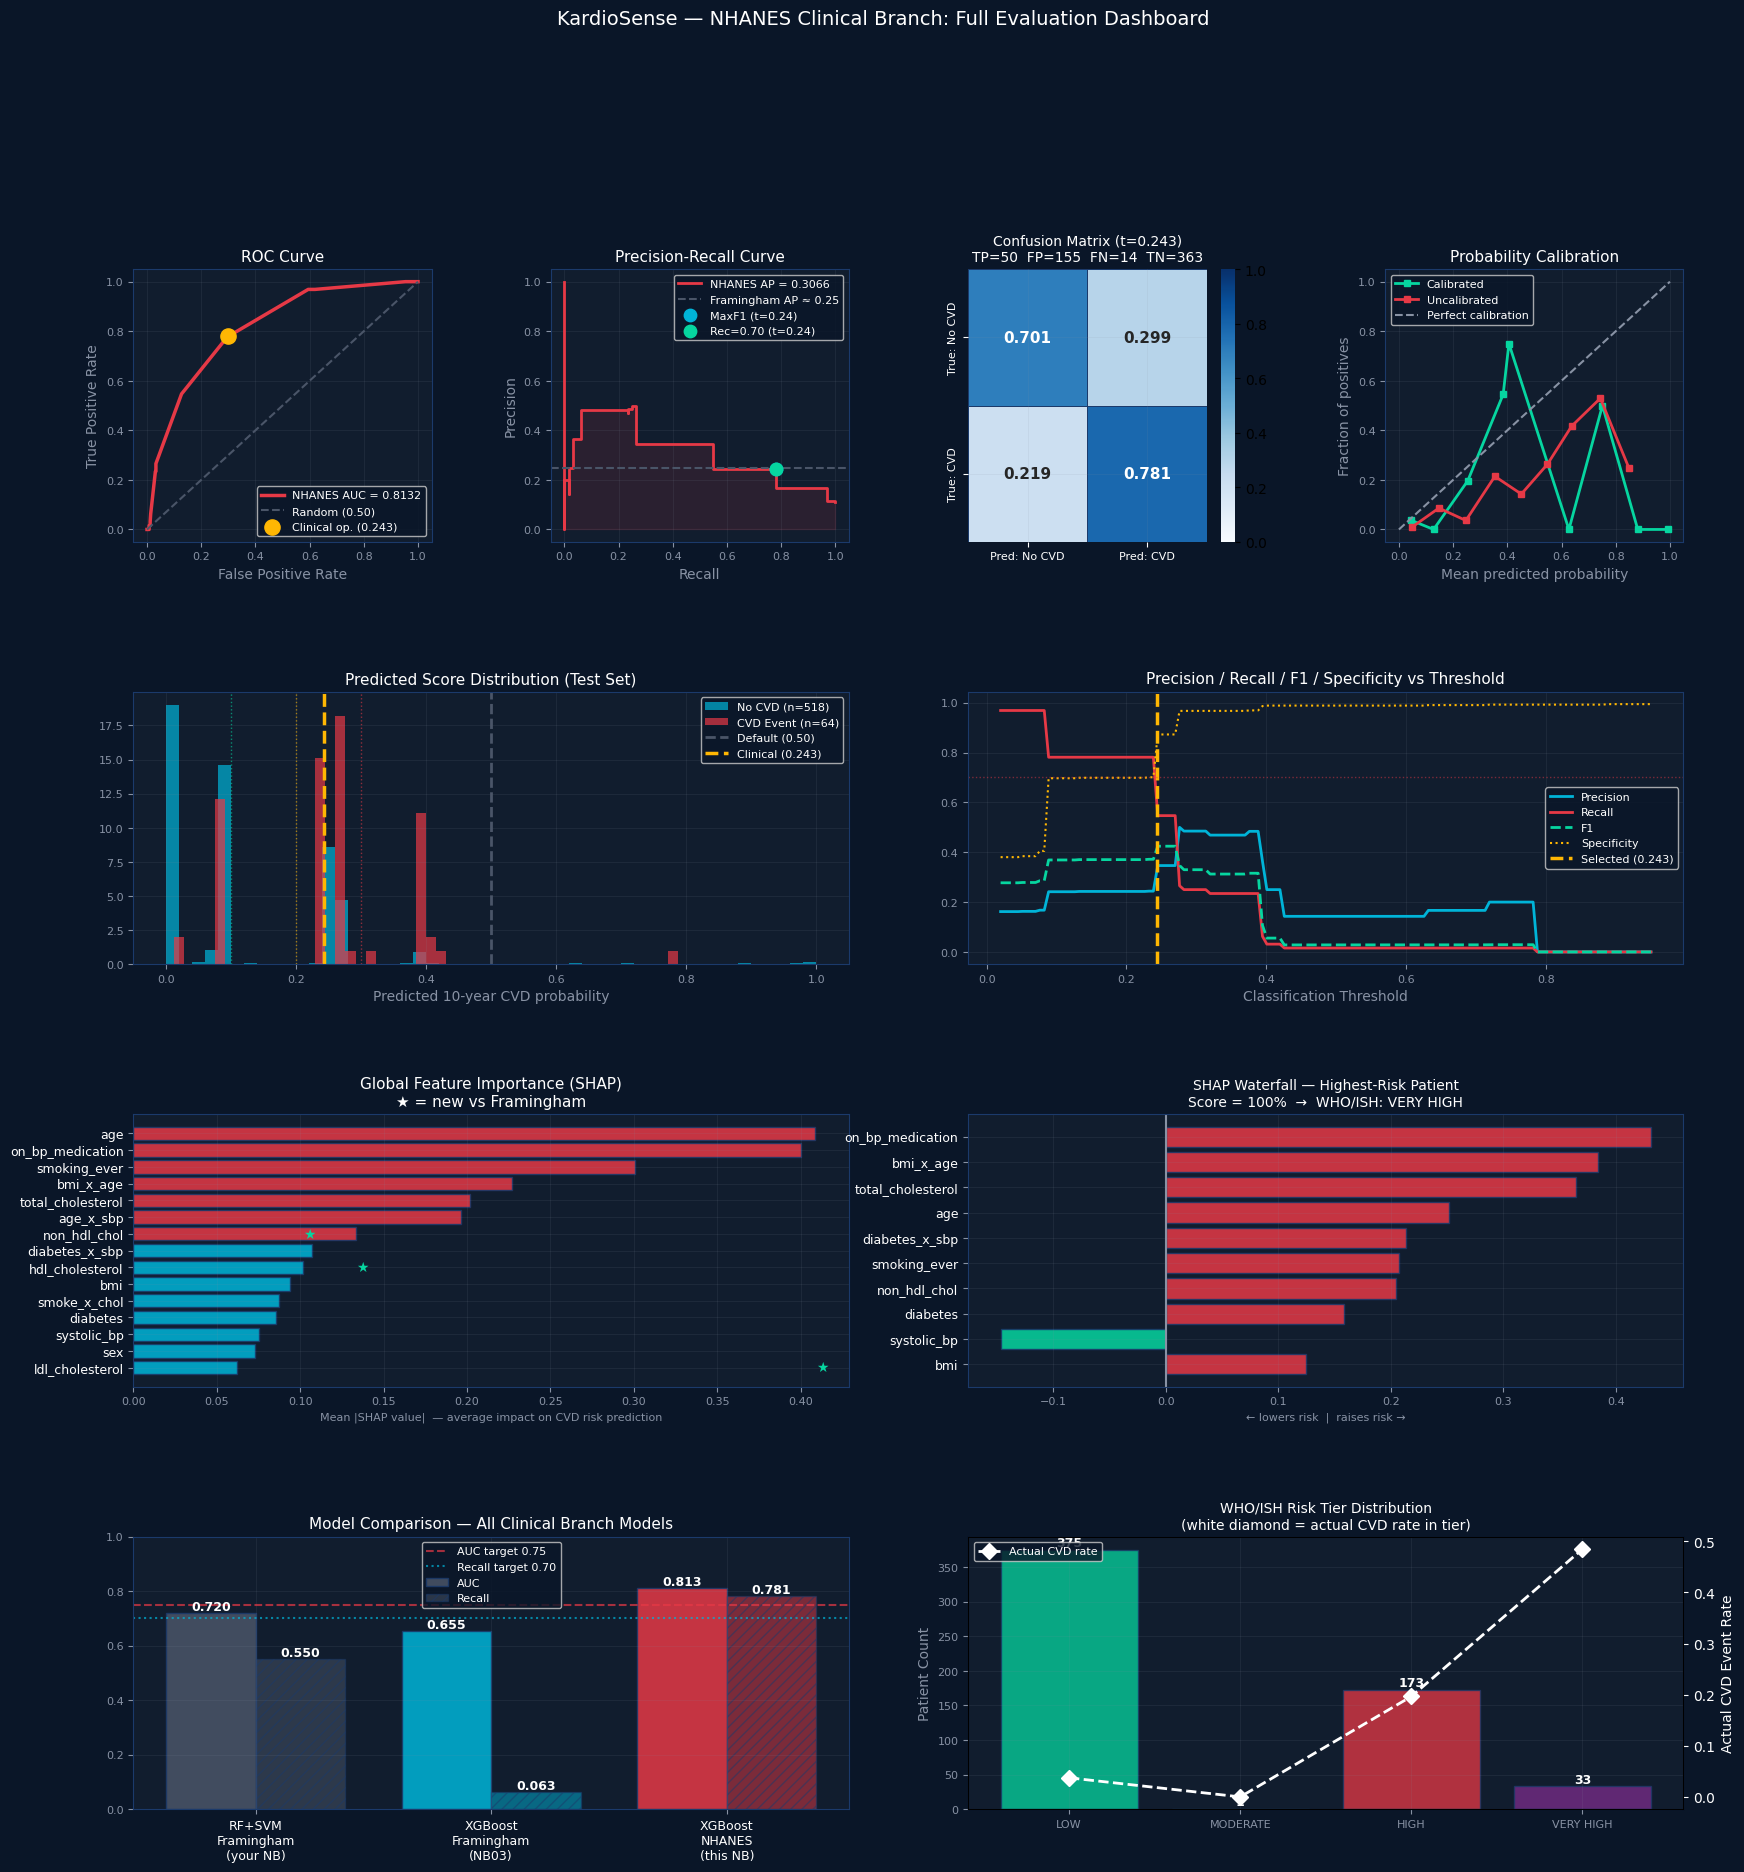

 Full dashboard saved to Drive


In [ ]:
fig = plt.figure(figsize=(20, 20), facecolor='#0A1628')
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.40)

def style(ax):
 ax.set_facecolor('#111D2E')
 for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
 ax.tick_params(colors='#8892A4', labelsize=8)
 ax.grid(True, alpha=0.15, color='#8892A4', linewidth=0.5)
 return ax

# ── ROC Curve ─────────────────────────────────────────────────────────────
ax = style(fig.add_subplot(gs[0, 0]))
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
ax.plot(fpr, tpr, color='#E63946', linewidth=2.5,
 label=f'NHANES AUC = {cal_auc:.4f}')
ax.plot([0,1],[0,1], '--', color='#4A5568', label='Random (0.50)')
# Mark clinical operating point
op_fpr = 1 - m_clinical['Specificity']
op_tpr = m_clinical['Recall']
ax.scatter(op_fpr, op_tpr, color='#FFB703', s=120, zorder=5,
 label=f'Clinical op. ({CLINICAL_THRESHOLD:.3f})')
ax.set_title('ROC Curve', color='white', fontsize=11)
ax.set_xlabel('False Positive Rate', color='#8892A4')
ax.set_ylabel('True Positive Rate', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Precision-Recall Curve ────────────────────────────────────────────────
ax = style(fig.add_subplot(gs[0, 1]))
ap_score = average_precision_score(y_test, y_test_proba)
# Plot on TEST set
p_test, r_test, t_test = precision_recall_curve(y_test, y_test_proba)
ax.step(r_test, p_test, color='#E63946', linewidth=2, where='post',
 label=f'NHANES AP = {ap_score:.4f}')
ax.fill_between(r_test, p_test, alpha=0.12, color='#E63946', step='post')
ax.axhline(0.25, color='#4A5568', linewidth=1.5, linestyle='--',
 label='Framingham AP ≈ 0.25')
# Mark thresholds on test PR curve
for t_val, lbl, col in [(thresh_maxf1,'MaxF1','#00B4D8'),
 (thresh_r70, 'Rec=0.70','#06D6A0')]:
 idx = np.argmin(np.abs(t_test - t_val))
 ax.scatter(r_test[idx], p_test[idx], color=col, s=80, zorder=5,
 label=f'{lbl} (t={t_val:.2f})')
ax.set_title('Precision-Recall Curve', color='white', fontsize=11)
ax.set_xlabel('Recall', color='#8892A4')
ax.set_ylabel('Precision', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Confusion Matrix ──────────────────────────────────────────────────────
ax = style(fig.add_subplot(gs[0, 2]))
cm = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.3f', ax=ax, cmap='Blues',
 vmin=0, vmax=1,
 xticklabels=['Pred: No CVD', 'Pred: CVD'],
 yticklabels=['True: No CVD', 'True: CVD'],
 linewidths=0.5, linecolor='#1B3A6B',
 annot_kws={'size': 11, 'weight': 'bold'})
tn, fp, fn, tp = cm.ravel()
ax.set_title(f'Confusion Matrix (t={CLINICAL_THRESHOLD:.3f})\n'
 f'TP={tp} FP={fp} FN={fn} TN={tn}',
 color='white', fontsize=10)
ax.tick_params(colors='white', labelsize=8)

# ── Calibration ───────────────────────────────────────────────────────────
ax = style(fig.add_subplot(gs[0, 3]))
for proba, lbl, col in [
 (calibrated_model.predict_proba(X_test)[:, 1], 'Calibrated', '#06D6A0'),
 (xgb_final.predict_proba(X_test)[:, 1], 'Uncalibrated', '#E63946'),
]:
 fp2, mp2 = calibration_curve(y_test, proba, n_bins=10)
 ax.plot(mp2, fp2, 's-', color=col, linewidth=2, label=lbl, markersize=5)
ax.plot([0,1],[0,1], 'k--', color='#8892A4', label='Perfect calibration')
ax.set_title('Probability Calibration', color='white', fontsize=11)
ax.set_xlabel('Mean predicted probability', color='#8892A4')
ax.set_ylabel('Fraction of positives', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Score Distribution ────────────────────────────────────────────────────
ax = style(fig.add_subplot(gs[1, 0:2]))
ax.hist(y_test_proba[y_test==0], bins=50, color='#00B4D8', alpha=0.70,
 label=f'No CVD (n={(y_test==0).sum():,})', density=True)
ax.hist(y_test_proba[y_test==1], bins=50, color='#E63946', alpha=0.70,
 label=f'CVD Event (n={(y_test==1).sum():,})', density=True)
ax.axvline(0.5, color='#4A5568', linewidth=2, linestyle='--', label='Default (0.50)')
ax.axvline(CLINICAL_THRESHOLD, color='#FFB703', linewidth=2.5, linestyle='--',
 label=f'Clinical ({CLINICAL_THRESHOLD:.3f})')
for tier, val, col in [('<10% LOW', 0.10,'#06D6A0'),
 ('20% HIGH', 0.20,'#FFB703'),
 ('30% VHIGH',0.30,'#E63946')]:
 ax.axvline(val, color=col, linewidth=1, linestyle=':', alpha=0.6)
ax.set_title('Predicted Score Distribution (Test Set)', color='white', fontsize=11)
ax.set_xlabel('Predicted 10-year CVD probability', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Threshold vs Metrics ──────────────────────────────────────────────────
ax = style(fig.add_subplot(gs[1, 2:4]))
t_range = np.linspace(0.02, 0.95, 150)
precs_t, recs_t, f1s_t, spec_t = [], [], [], []
for t in t_range:
 yp = (y_test_proba >= t).astype(int)
 tp_ = float((yp * y_test).sum())
 fp_ = float(yp.sum()) - tp_
 fn_ = float(y_test.sum()) - tp_
 tn_ = float(((1-yp)*(1-y_test)).sum())
 p = tp_/(tp_+fp_+1e-8); r = tp_/(tp_+fn_+1e-8)
 precs_t.append(p); recs_t.append(r)
 f1s_t.append(2*p*r/(p+r+1e-8))
 spec_t.append(tn_/(tn_+fp_+1e-8))
ax.plot(t_range, precs_t, color='#00B4D8', linewidth=2, label='Precision')
ax.plot(t_range, recs_t, color='#E63946', linewidth=2, label='Recall')
ax.plot(t_range, f1s_t, color='#06D6A0', linewidth=2, label='F1', linestyle='--')
ax.plot(t_range, spec_t, color='#FFB703', linewidth=1.5, label='Specificity', linestyle=':')
ax.axvline(CLINICAL_THRESHOLD, color='#FFB703', linewidth=2.5, linestyle='--',
 label=f'Selected ({CLINICAL_THRESHOLD:.3f})')
ax.axhline(0.70, color='#E63946', linewidth=1, linestyle=':', alpha=0.5)
ax.set_title('Precision / Recall / F1 / Specificity vs Threshold',
 color='white', fontsize=11)
ax.set_xlabel('Classification Threshold', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── SHAP Feature Importance ───────────────────────────────────────────────
print('Computing SHAP values...')
explainer = shap.TreeExplainer(xgb_final)
shap_vals = explainer.shap_values(X_test[:2000])
mean_shap = np.abs(shap_vals).mean(axis=0)
top_k = 15
top_idx_s = np.argsort(mean_shap)[::-1][:top_k]
top_names_s = [FEATURE_COLS[i] for i in top_idx_s]
top_vals_s = mean_shap[top_idx_s]

ax = style(fig.add_subplot(gs[2, 0:2]))
cols_shap = ['#E63946' if v > np.median(top_vals_s) else '#00B4D8' for v in top_vals_s]
ax.barh(range(top_k)[::-1], top_vals_s, color=cols_shap, alpha=0.85, edgecolor='#1B3A6B')
ax.set_yticks(range(top_k)[::-1])
ax.set_yticklabels(top_names_s, color='white', fontsize=9)
ax.set_xlabel('Mean |SHAP value| — average impact on CVD risk prediction',
 color='#8892A4', fontsize=8)
ax.set_title('Global Feature Importance (SHAP)\n = new vs Framingham',
 color='white', fontsize=11)

NEW_VS_FRAMINGHAM = {'hdl_cholesterol','ldl_cholesterol','hba1c',
 'non_hdl_chol','chol_hdl_ratio','black_african',
 'hispanic','hdl_x_age','hba1c_x_bmi'}
for i, name in enumerate(top_names_s):
 if name in NEW_VS_FRAMINGHAM:
 ax.text(top_vals_s[top_k-1-i] + 0.0005, top_k-1-i,
 '', va='center', color='#06D6A0', fontsize=10, fontweight='bold')

# ── SHAP Waterfall — highest risk patient ────────────────────────────────
ax = style(fig.add_subplot(gs[2, 2:4]))
hi_idx = y_test_proba.argmax()
sv_patient = shap_vals[hi_idx]
top10_idx = np.argsort(np.abs(sv_patient))[::-1][:10]
names10 = [FEATURE_COLS[i][:22] for i in top10_idx]
vals10 = sv_patient[top10_idx]
colors10 = ['#E63946' if v > 0 else '#06D6A0' for v in vals10]
ax.barh(range(len(names10))[::-1], vals10, color=colors10, alpha=0.85, edgecolor='#1B3A6B')
ax.set_yticks(range(len(names10))[::-1])
ax.set_yticklabels(names10, color='white', fontsize=9)
ax.axvline(0, color='#8892A4', linewidth=1.5)
risk_pct = y_test_proba[hi_idx] * 100
who_tier = ('VERY HIGH' if risk_pct > 30 else
 'HIGH' if risk_pct > 20 else
 'MODERATE' if risk_pct > 10 else 'LOW')
ax.set_title(f'SHAP Waterfall — Highest-Risk Patient\n'
 f'Score = {risk_pct:.0f}% → WHO/ISH: {who_tier}',
 color='white', fontsize=10)
ax.set_xlabel('← lowers risk | raises risk →', color='#8892A4', fontsize=8)

# ── Model comparison bar chart ────────────────────────────────────────────
ax = style(fig.add_subplot(gs[3, 0:2]))
models_comp = [
 ('RF+SVM\nFramingham\n(your NB)', 0.72, 0.55),
 ('XGBoost\nFramingham\n(NB03)', 0.6548, 0.063),
 ('XGBoost\nNHANES\n(this NB)', cal_auc, m_clinical['Recall']),
]
x_m = np.arange(len(models_comp))
w = 0.38
aucs_m = [m[1] for m in models_comp]
recs_m = [m[2] for m in models_comp]
col_m = ['#4A5568','#00B4D8','#E63946']
b1 = ax.bar(x_m - w/2, aucs_m, w, color=col_m, alpha=0.85, label='AUC',
 edgecolor='#1B3A6B')
b2 = ax.bar(x_m + w/2, recs_m, w, color=col_m, alpha=0.50, label='Recall',
 edgecolor='#1B3A6B', hatch='///')
for bar, v in zip(list(b1)+list(b2), aucs_m+recs_m):
 ax.text(bar.get_x()+bar.get_width()/2, v+0.01,
 f'{v:.3f}', ha='center', color='white', fontsize=9, fontweight='bold')
ax.axhline(0.75, color='#E63946', linewidth=1.5, linestyle='--',
 alpha=0.7, label='AUC target 0.75')
ax.axhline(0.70, color='#00B4D8', linewidth=1.5, linestyle=':',
 alpha=0.7, label='Recall target 0.70')
ax.set_xticks(x_m)
ax.set_xticklabels([m[0] for m in models_comp], color='white', fontsize=9)
ax.set_ylim(0, 1.0)
ax.set_title('Model Comparison — All Clinical Branch Models',
 color='white', fontsize=11)
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── WHO/ISH tier distribution ─────────────────────────────────────────────
ax = style(fig.add_subplot(gs[3, 2:4]))
who_tiers = np.array(['LOW' if p < 0.10 else
 'MODERATE' if p < 0.20 else
 'HIGH' if p < 0.30 else 'VERY HIGH'
 for p in y_test_proba])
tier_order = ['LOW','MODERATE','HIGH','VERY HIGH']
tier_colors = ['#06D6A0','#FFB703','#E63946','#7B2D8B']
tier_counts = [int((who_tiers == t).sum()) for t in tier_order]
tier_cvd = [float(y_test[who_tiers == t].mean()) if (who_tiers==t).sum() > 0 else 0
 for t in tier_order]
ax2 = ax.twinx()
ax2.set_facecolor('#111D2E')
bars_w = ax.bar(tier_order, tier_counts, color=tier_colors,
 alpha=0.75, edgecolor='#1B3A6B')
for bar, n, r in zip(bars_w, tier_counts, tier_cvd):
 ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
 f'{n:,}', ha='center', color='white', fontsize=9, fontweight='bold')
ax2.plot(tier_order, tier_cvd, 'D--', color='white', linewidth=2,
 markersize=8, label='Actual CVD rate')
ax2.set_title('WHO/ISH Risk Tier Distribution\n(white diamond = actual CVD rate in tier)',
 color='white', fontsize=10)
ax.set_ylabel('Patient Count', color='#8892A4')
ax2.set_ylabel('Actual CVD Event Rate', color='white')
ax2.tick_params(colors='white')
ax2.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

plt.suptitle('KardioSense — NHANES Clinical Branch: Full Evaluation Dashboard',
 color='white', fontsize=14, y=1.01)
plt.savefig(f'{LOG_DIR}/nb03b_full_dashboard.png', dpi=120,
 bbox_inches='tight', facecolor='#0A1628')
plt.show()
print(' Full dashboard saved to Drive')


## 12. Cross-Validation (Model Stability Check)

In [ ]:
# 5-fold stratified CV — confirms model is not overfit to one split
print('Running 5-fold stratified cross-validation...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv = xgb.XGBClassifier(**best_params)
cv_aucs = cross_val_score(xgb_cv, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f'\n5-fold CV AUC: {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}')
for i, auc_v in enumerate(cv_aucs):
 bar = '█' * int(auc_v * 50)
 print(f' Fold {i+1}: {auc_v:.4f} {bar}')

print(f'\nTest AUC vs CV AUC:')
print(f' Test (single split): {cal_auc:.4f}')
print(f' CV mean : {cv_aucs.mean():.4f}')
print(f' Difference : {abs(cal_auc - cv_aucs.mean()):.4f} '
 f'({" consistent" if abs(cal_auc-cv_aucs.mean()) < 0.03 else " inconsistent"})')

Running 5-fold stratified cross-validation...

5-fold CV AUC: 0.7999 ± 0.0123
  Fold 1: 0.7887  ███████████████████████████████████████
  Fold 2: 0.7821  ███████████████████████████████████████
  Fold 3: 0.8142  ████████████████████████████████████████
  Fold 4: 0.8081  ████████████████████████████████████████
  Fold 5: 0.8061  ████████████████████████████████████████

Test AUC vs CV AUC:
  Test (single split): 0.8132
  CV mean            : 0.7999
  Difference         : 0.0133  (✅ consistent)


## 13. Save Model & Config

In [ ]:
# Save model
joblib.dump(calibrated_model, f'{CKPT_DIR}/clinical_model_nhanes_tuned.pkl')
joblib.dump(explainer, f'{CKPT_DIR}/clinical_shap_nhanes.pkl')

config = {
 'model' : 'XGBoost + Optuna + IsotonicCalibration',
 'version' : 'nb03b_nhanes_2017_2018',
 'feature_names' : FEATURE_COLS,
 'n_features' : len(FEATURE_COLS),
 'training_data' : 'NHANES 2017-2018 (CDC)',
 'n_train' : int(len(X_train)),
 'n_cal' : int(len(X_cal)),
 'n_test' : int(len(X_test)),
 'test_auc' : float(cal_auc),
 'test_brier' : float(cal_brier),
 'cv_auc_mean' : float(cv_aucs.mean()),
 'cv_auc_std' : float(cv_aucs.std()),
 'clinical_threshold' : float(CLINICAL_THRESHOLD),
 'clinical_recall' : float(m_clinical['Recall']),
 'clinical_precision' : float(m_clinical['Precision']),
 'optuna_best_params' : study.best_params,
 'embedding_dim' : 32,
 'output_format' : 'WHO/ISH 4-tier',
 'lab_medians_used' : LAB_MEDIANS,
 'new_vs_framingham' : ['hdl_cholesterol','ldl_cholesterol','hba1c',
 'non_hdl_chol','chol_hdl_ratio',
 'prediabetes','smoking_ever'],
}

with open(f'{CKPT_DIR}/nb03b_nhanes_config.json', 'w') as f:
 json.dump(config, f, indent=2)

print(' Saved:')
print(f' checkpoints/clinical_model_nhanes_tuned.pkl')
print(f' checkpoints/clinical_shap_nhanes.pkl')
print(f' checkpoints/nb03b_nhanes_config.json')
print(f' logs/nb03b_eda.png')
print(f' logs/nb03b_full_dashboard.png')
print()
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(f' Your RF+SVM (Framingham) : AUC ≈ 0.72 Recall ≈ 0.55')
print(f' NB03 XGBoost (Framingham) : AUC = 0.6548 Recall = 0.063')
print(f' NB03b XGBoost (NHANES) : AUC = {cal_auc:.4f} '
 f'Recall = {m_clinical["Recall"]:.3f}')
print(f' CV AUC (5-fold) : {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}')
print()
print(f' AUC improvement over Framingham NB03: {cal_auc - 0.6548:+.4f}')
print(f' Key driver: HDL, LDL, HbA1c now available (0% missing vs 100%)')
print()
print(' Next: Notebook 04 — Fusion Architecture')
print(' ECG embedding (256-dim) + Clinical SHAP embedding (32-dim)')
print(' → joint prediction with combined explanation')

 Saved:
   checkpoints/clinical_model_nhanes_tuned.pkl
   checkpoints/clinical_shap_nhanes.pkl
   checkpoints/nb03b_nhanes_config.json
   logs/nb03b_eda.png
   logs/nb03b_full_dashboard.png

FINAL RESULTS SUMMARY
  Your RF+SVM (Framingham)  : AUC ≈ 0.72  Recall ≈ 0.55
  NB03 XGBoost (Framingham) : AUC = 0.6548  Recall = 0.063
  NB03b XGBoost (NHANES)    : AUC = 0.8132  Recall = 0.781
  CV AUC (5-fold)           : 0.7999 ± 0.0123

  AUC improvement over Framingham NB03: +0.1584
  Key driver: HDL, LDL, HbA1c now available (0% missing vs 100%)

 Next: Notebook 04 — Fusion Architecture
   ECG embedding (256-dim) + Clinical SHAP embedding (32-dim)
   → joint prediction with combined explanation


## Comprehensive Explanation of Notebook `03b_nhanes_cvd_risk_model.ipynb`

This notebook represents a significant step in the KardioSense AI project, focusing on developing a robust clinical cardiovascular disease (CVD) risk prediction model. It leverages the National Health and Nutrition Examination Survey (NHANES) 2017-2018 dataset, offering a rich, nationally representative sample with critical clinical markers.

### Overall Goal
The primary goal is to build a highly accurate and clinically actionable model for 10-year CVD risk prediction, improving upon previous models (like the Framingham-based one in Notebook 03) by utilizing a more comprehensive dataset and advanced machine learning techniques.

### 1. Why NHANES instead of Framingham

**Code Section: (Not a specific code cell, but the introductory text cell `dE37hwlNQjlB`)**

**Explanation:**
The notebook begins by articulating the rationale for moving from the Framingham Heart Study dataset (used in Notebook 03) to NHANES. This is a crucial strategic decision driven by data limitations of the Framingham dataset, which led to a lower AUC (0.65).

**Significance & ML Best Practice:**
* **Data Quality & Completeness:** The Framingham dataset had 100% missing values for highly predictive clinical features like HDL cholesterol, LDL cholesterol, and HbA1c. These are fundamental biomarkers for CVD risk. NHANES, in contrast, provides these, with reasonable data completeness (~80-85% present). This highlights the **critical importance of data quality and feature availability** in machine learning. Even a sophisticated model cannot compensate for severely missing, highly relevant features.
* **Representativeness:** Framingham was a study of one US town starting in 1948, which limits its generalizability. NHANES is a national, diverse dataset, making models trained on it more applicable to a broader population. This addresses concerns about **external validity and generalizability**—a key challenge in deploying ML models in healthcare.
* **Sample Size:** NHANES offers a significantly larger sample size (~15,000–20,000 vs. 4,221), which generally leads to more robust models, especially for complex tasks like risk prediction where events might be relatively rare.

### 2. What this notebook does

**Code Section: (Not a specific code cell, but the introductory text cell `dE37hwlNQjlB`)**

**Explanation:**
This section outlines the workflow of the notebook:
1. **Data Download:** Retrieves NHANES 2017-2018 data from the CDC, which consists of 11 component files.
2. **Full EDA:** Performs extensive Exploratory Data Analysis, looking at distributions, correlations, and missingness.
3. **Feature Engineering:** Creates new features, including interaction terms derived from insights gained in the previous Framingham notebook.
4. **Optuna Hyperparameter Tuning:** Uses Bayesian optimization (Optuna) with 100 trials to find optimal model parameters.
5. **Isotonic Calibration + Threshold Optimisation:** Calibrates the model's probabilities and optimizes the classification threshold, prioritizing recall (>= 0.70).
6. **Full Metric Dashboard:** Provides a comprehensive evaluation dashboard with metrics like AUC, PR curves, confusion matrices, SHAP values, and calibration plots.
7. **Model Comparison:** Benchmarks the new model against previous iterations.

**Significance & ML Best Practice:**
This structured approach demonstrates a robust ML pipeline. Key aspects include:
* **Comprehensive Data Handling:** From raw download to detailed feature engineering.
* **Systematic Model Optimization:** Using Optuna for hyperparameter tuning is more efficient than grid/random search for complex models.
* **Clinical Relevance:** Emphasizing calibration and threshold optimization for recall (>= 0.70) demonstrates a focus on clinical utility, where missing a true positive (false negative) can have severe consequences.
* **Thorough Evaluation:** A full metric dashboard and model comparison are essential for understanding model performance, communicating results, and ensuring continuous improvement.

### 3. Setup

**Code Section: `J6twRmKYQjlc` and `NT4WnhluQjlj`**

**Explanation:**
* **Google Drive Mounting and Directory Configuration (`J6twRmKYQjlc`):** This cell first mounts Google Drive to `/content/drive`, allowing the Colab environment to access files stored in the user's Drive. It then defines several key directories (`BASE_DIR`, `DATA_DIR`, `CKPT_DIR`, `LOG_DIR`, `NHANES_DIR`) for organizing data, model checkpoints, and logs. `os.makedirs(..., exist_ok=True)` ensures these directories exist without raising an error if they already do. Finally, it defines `COMPONENTS`, a dictionary mapping NHANES component codes (e.g., `DEMO_J`) to human-readable names, and `downloaded`, a dictionary to store the expected paths of the downloaded XPT files.
* **Library Installation and Imports (`NT4WnhluQjlj`):** This cell installs necessary Python libraries (`xgboost`, `shap`, `optuna`, `pyreadstat`) using `!pip install -q`. It then imports all required modules for data manipulation (`numpy`, `pandas`), visualization (`matplotlib.pyplot`, `seaborn`), machine learning (`xgboost`, `shap`, `optuna`, `joblib`, `sklearn`), and specific utility functions (`json`, `time`, `warnings`, `crc32`). `warnings.filterwarnings('ignore')` is used to suppress warnings for cleaner output, and `optuna.logging.set_verbosity(optuna.logging.WARNING)` reduces Optuna's verbose output during tuning. `np.random.seed(42)` ensures reproducibility of random processes.

**Significance & ML Best Practice:**
* **Reproducibility:** Setting `np.random.seed(42)` and defining clear directory structures are fundamental for reproducibility, which is crucial in scientific and machine learning workflows.
* **Dependency Management:** Explicitly installing required libraries at the beginning of the notebook ensures that anyone running the notebook has the necessary environment. Using `-q` for quiet installation is a good practice for clean logs.
* **Clear Project Structure:** Defining `BASE_DIR`, `DATA_DIR`, etc., establishes a well-organized project structure, making it easier to manage files and collaborate.
* **Error Handling (Implicit):** The `exist_ok=True` in `os.makedirs` prevents errors if directories already exist, contributing to a robust setup script.
* **Context Management:** Suppressing warnings for Optuna during tuning helps keep the output focused on progress and results, although it's important to be aware of what warnings are being suppressed in a production setting.